In [3]:
# SETUP
import os, json, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
from sklearn.metrics import accuracy_score

# Config
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Load dataset
try:
    ds
except NameError:
    ds = load_dataset("leondz/wnut_17", revision="refs/convert/parquet")

# Load model/pipeline
try:
    ner_pipe
except NameError:
    model_name = "dslim/bert-base-NER"
    tok = AutoTokenizer.from_pretrained(model_name)
    mdl = AutoModelForTokenClassification.from_pretrained(model_name)
    ner_pipe = pipeline("ner", model=mdl, tokenizer=tok, aggregation_strategy="simple")

label_names = ds["train"].features["ner_tags"].feature.names  # fine-grained WNUT-17 tags

# Fine to coarse mapping
def map_wnut_to_coarse(tag):
    if tag == "O": return "O"
    base = tag.split("-", 1)[-1]
    if base == "person": return "PER"
    if base == "location": return "LOC"
    if base in ("corporation", "group"): return "ORG"
    if base in ("product", "creative-work"): return "MISC"
    return "MISC"

# Masking helpers (gold-guided)
def mask_entity_tokens(tokens, gold_ids):
    return ["[MASK]" if label_names[i] != "O" else t for t, i in zip(tokens, gold_ids)]

def mask_context_tokens(tokens, gold_ids):
    return ["[MASK]" if label_names[i] == "O" else t for t, i in zip(tokens, gold_ids)]

# Align pipeline spans to tokens; return coarse labels per token
def get_token_labels(tokens, ner_output, sentence):
    labels = ["O"] * len(tokens)

    # compute token character spans by left-to-right find
    spans = []
    cursor = 0
    for t in tokens:
        pos = sentence.find(t, cursor)

        # if not found, don't poison the cursor; mark span as None
        if pos == -1:
            spans.append((None, None))
            continue

        start = pos
        end = pos + len(t)
        spans.append((start, end))
        cursor = end

    # assign entity label if token span overlaps entity span
    for ent in ner_output:
        s, e = ent["start"], ent["end"]
        lab = ent["entity_group"]

        for i, (ts, te) in enumerate(spans):
            if ts is None:
                continue
            # overlap test (robust to punctuation boundary differences)
            if ts < e and te > s:
                labels[i] = lab

    return labels

# Accuracy only on entity positions
def filtered_accuracy(gold_labels, pred_labels):
    idx = [i for i, g in enumerate(gold_labels) if g != "O"]
    if not idx: return np.nan
    g = [gold_labels[i] for i in idx]
    p = [pred_labels[i] for i in idx]
    return accuracy_score(g, p)

# Bootstrap mean CI
def boot_mean_ci(x, n_boot=2000, alpha=0.05, rng_=None):
    x = np.array([v for v in x if not (isinstance(v, float) and math.isnan(v))], dtype=float)
    if len(x) == 0:
        return np.nan, (np.nan, np.nan)
    rng_ = rng_ or np.random.default_rng(RNG_SEED)
    means = []
    for _ in range(n_boot):
        sample = rng_.choice(x, size=len(x), replace=True)
        means.append(sample.mean())
    lo, hi = np.percentile(means, [100*alpha/2, 100*(1-alpha/2)])
    return float(np.mean(x)), (float(lo), float(hi))

os.makedirs("results", exist_ok=True)
print("Setup complete.")


Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


Setup complete.


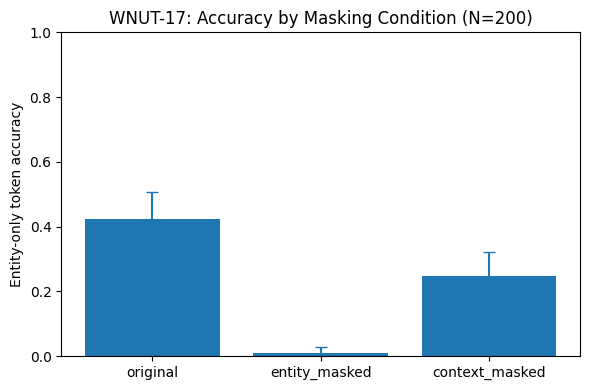

Saved: results/accuracy_masking_bar.png, results/accuracy_by_sentence.csv, results/accuracy_summary.json


In [4]:
# OVERALL ACCURACY with 95% CIs
N = 200 
test_size = len(ds["test"])
indices = rng.choice(test_size, size=min(N, test_size), replace=False)
subset = ds["test"].select(sorted(indices.tolist()))

rows = []
for ex in subset:
    tokens = ex["tokens"]
    gold_ids = ex["ner_tags"]
    sent = " ".join(tokens)
    gold_labels = [map_wnut_to_coarse(label_names[i]) for i in gold_ids]

    # Original
    pred_orig = get_token_labels(tokens, ner_pipe(sent), sent)

    # Entity-masked
    ent_tokens = mask_entity_tokens(tokens, gold_ids)
    ent_masked = " ".join(ent_tokens)
    pred_ent   = get_token_labels(ent_tokens, ner_pipe(ent_masked), ent_masked)

    # Context-masked
    ctx_tokens = mask_context_tokens(tokens, gold_ids)
    ctx_masked = " ".join(ctx_tokens)
    pred_ctx   = get_token_labels(ctx_tokens, ner_pipe(ctx_masked), ctx_masked)

    rows.append({
        "original":        filtered_accuracy(gold_labels, pred_orig),
        "entity_masked":   filtered_accuracy(gold_labels, pred_ent),
        "context_masked":  filtered_accuracy(gold_labels, pred_ctx),
    })

df = pd.DataFrame(rows)
summary = {}
for col in ["original", "entity_masked", "context_masked"]:
    m, (lo, hi) = boot_mean_ci(df[col], n_boot=2000, alpha=0.05, rng_=rng)
    summary[col] = {"mean": m, "ci_low": lo, "ci_high": hi}

drop_entity  = summary["original"]["mean"] - summary["entity_masked"]["mean"]
drop_context = summary["original"]["mean"] - summary["context_masked"]["mean"]

conds = ["original", "entity_masked", "context_masked"]
means = [summary[c]["mean"] for c in conds]
yerr  = [[summary[c]["mean"] - summary[c]["ci_low"] for c in conds],
         [summary[c]["ci_high"] - summary[c]["mean"] for c in conds]]

plt.figure(figsize=(6, 4))
plt.bar(conds, means)
plt.errorbar(conds, means, yerr=yerr, fmt="none", capsize=4)
plt.ylabel("Entity-only token accuracy")
plt.title(f"WNUT-17: Accuracy by Masking Condition (N={len(df)})")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("results/accuracy_masking_bar.png", dpi=300)
plt.show()

df.to_csv("results/accuracy_by_sentence.csv", index=False)
with open("results/accuracy_summary.json", "w") as f:
    json.dump({"summary": summary, "drops": {"entity": drop_entity, "context": drop_context}}, f, indent=2)
print("Saved: results/accuracy_masking_bar.png, results/accuracy_by_sentence.csv, results/accuracy_summary.json")

Mean entity-only token accuracy by type


,original,entity_masked,context_masked
entity_type,,,
PER,0.545455,0.000000,0.375000
ORG,0.447368,0.026316,0.342105
LOC,0.305556,0.000000,0.166667
MISC,0.205128,0.000000,0.141026


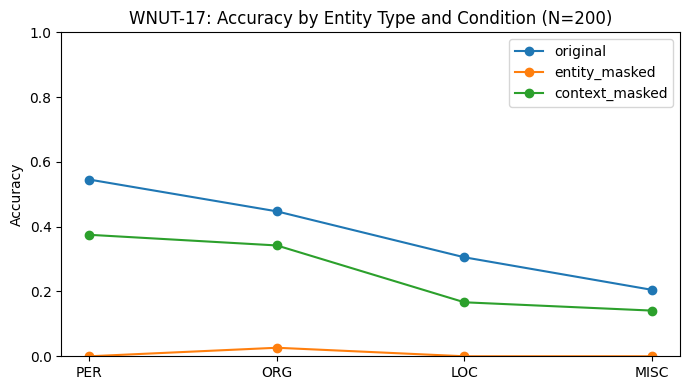

Saved: results/accuracy_by_type.png, results/accuracy_by_type.csv, results/token_level_results.csv


In [5]:
# PER-ENTITY-TYPE ACCURACY
per_token_rows = []

for ex in subset:
    tokens = ex["tokens"]
    gold_ids = ex["ner_tags"]
    sent = " ".join(tokens)
    gold_labels = [map_wnut_to_coarse(label_names[i]) for i in gold_ids]

    # Original
    pred_orig = get_token_labels(tokens, ner_pipe(sent), sent)

    # Entity-masked
    ent_tokens = mask_entity_tokens(tokens, gold_ids)
    ent_masked = " ".join(ent_tokens)
    pred_ent   = get_token_labels(ent_tokens, ner_pipe(ent_masked), ent_masked)

    # Context-masked
    ctx_tokens = mask_context_tokens(tokens, gold_ids)
    ctx_masked = " ".join(ctx_tokens)
    pred_ctx   = get_token_labels(ctx_tokens, ner_pipe(ctx_masked), ctx_masked)

    # Record correctness only at gold entity positions, grouped by gold coarse type
    for i, g in enumerate(gold_labels):
        if g == "O":
            continue
        per_token_rows.append({
            "entity_type": g,
            "original": float(pred_orig[i] == g),
            "entity_masked": float(pred_ent[i] == g),
            "context_masked": float(pred_ctx[i] == g),
        })

per_tok = pd.DataFrame(per_token_rows)

by_type = (
    per_tok
    .groupby("entity_type")[["original", "entity_masked", "context_masked"]]
    .mean()
    .reindex(["PER", "ORG", "LOC", "MISC"])
)

print("Mean entity-only token accuracy by type")
display(by_type)

# Plot
plt.figure(figsize=(7, 4))
for cond in ["original", "entity_masked", "context_masked"]:
    plt.plot(by_type.index, by_type[cond], marker="o", label=cond)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title(f"WNUT-17: Accuracy by Entity Type and Condition (N={len(subset)})")
plt.legend()
plt.tight_layout()
plt.savefig("results/accuracy_by_type.png", dpi=300)
plt.show()

# Save
by_type.reset_index().to_csv("results/accuracy_by_type.csv", index=False)
per_tok.to_csv("results/token_level_results.csv", index=False)
print("Saved: results/accuracy_by_type.png, results/accuracy_by_type.csv, results/token_level_results.csv")

In [4]:
# PROBING SUITE: ambiguous, unseen, contradictory; with masked-context comparison
def run_ner(s): 
    return [{"word": e["word"], "label": e["entity_group"], "score": float(e["score"])} for e in ner_pipe(s)]

def mask_context_sentence(sentence, entity_words):
    return " ".join(["[MASK]" if tok not in entity_words else tok for tok in sentence.split()])

ambiguous = [
    "Jordan scored the winning point in the final.",
    "Jordan signed a new trade deal with the EU.",
    "Apple released a new iPhone today.",
    "Apple is expanding its farmland in California.",
    "Amazon hired 1,000 engineers in Seattle.",
    "Amazon is the longest river in South America."
]
unseen = [
    "Orchidia led the team to victory.",
    "Orchidia acquired 12 new subsidiaries.",
    "Noventis LLC signed a billion-dollar defense contract.",
    "Noventis LLC is a myth from ancient tales."
]
contradictory = [
    "Jordan is a famous athlete from the US.",
    "Jordan is a Middle Eastern country.",
    "Apple is known for its sweet taste and health benefits.",
    "Apple is a leader in consumer electronics."
]

records = []

def log_sentence(s, tag):
    # Original
    out = run_ner(s)
    entity_words = {e["word"] for e in out}
    masked = mask_context_sentence(s, entity_words) if entity_words else None
    out_masked = run_ner(masked) if masked else []
    records.append({
        "category": tag,
        "sentence": s,
        "pred_original": out,
        "pred_context_masked": out_masked,
        "context_masked_sentence": masked
    })

for s in ambiguous:   log_sentence(s, "ambiguous")
for s in unseen:      log_sentence(s, "unseen")
for s in contradictory: log_sentence(s, "contradictory")

# Save a readable CSV summary
rows = []
for r in records:
    def fmt(preds):
        return "; ".join(f"{p['word']}→{p['label']}({p['score']:.3f})" for p in preds) if preds else ""
    rows.append({
        "category": r["category"],
        "sentence": r["sentence"],
        "original_preds": fmt(r["pred_original"]),
        "context_masked_sentence": r["context_masked_sentence"] or "",
        "context_masked_preds": fmt(r["pred_context_masked"]),
    })
probe_df = pd.DataFrame(rows)
display(probe_df)

probe_df.to_csv("results/probing_summary.csv", index=False)
with open("results/probing_raw.json", "w") as f:
    json.dump(records, f, indent=2)
print("Saved: results/probing_summary.csv, results/probing_raw.json")


,category,sentence,original_preds,context_masked_sentence,context_masked_preds
0,ambiguous,Jordan scored the winning point in the final.,Jordan→ORG(0.661),Jordan [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,Jordan→ORG(0.993)
1,ambiguous,Jordan signed a new trade deal with the EU.,Jordan→LOC(1.000); EU→ORG(0.999),Jordan [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,Jordan→ORG(0.993)
2,ambiguous,Apple released a new iPhone today.,Apple→ORG(0.998); iPhone→MISC(0.985),Apple [MASK] [MASK] [MASK] iPhone [MASK],Apple→ORG(0.991); iPhone→MISC(0.857)
3,ambiguous,Apple is expanding its farmland in California.,Apple→ORG(0.997); California→LOC(1.000),Apple [MASK] [MASK] [MASK] [MASK] [MASK] [MASK],Apple→ORG(0.996)
4,ambiguous,"Amazon hired 1,000 engineers in Seattle.",Amazon→ORG(0.999); Seattle→LOC(0.999),Amazon [MASK] [MASK] [MASK] [MASK] [MASK],Amazon→ORG(0.991)
5,ambiguous,Amazon is the longest river in South America.,Amazon→LOC(0.993); South America→LOC(0.999),Amazon [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,Amazon→ORG(0.994)
6,unseen,Orchidia led the team to victory.,Or→ORG(0.799); ##dia→ORG(0.369),[MASK] [MASK] [MASK] [MASK] [MASK] [MASK],
7,unseen,Orchidia acquired 12 new subsidiaries.,Orchidia→ORG(0.995),Orchidia [MASK] [MASK] [MASK] [MASK],Orchidia→ORG(0.897)
8,unseen,Noventis LLC signed a billion-dollar defense c...,Noventis LLC→ORG(0.997),[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK],
9,unseen,Noventis LLC is a myth from ancient tales.,Noventis LLC→ORG(0.997),[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,


Saved: results/probing_summary.csv, results/probing_raw.json


In [5]:
# ILLUSTRATIVE EXAMPLES from WNUT-17 test set (original vs masked predictions)
examples = []
count = 0

for ex in ds["test"]:
    if count >= 10:
        break

    tokens = ex["tokens"]
    gold_ids = ex["ner_tags"]
    sent = " ".join(tokens)
    gold_labels = [map_wnut_to_coarse(label_names[i]) for i in gold_ids]

    # Original
    pred_o = get_token_labels(tokens, ner_pipe(sent), sent)

    # Entity-masked
    ent_tokens = mask_entity_tokens(tokens, gold_ids)
    ent_masked = " ".join(ent_tokens)
    pred_e = get_token_labels(ent_tokens, ner_pipe(ent_masked), ent_masked)

    # Context-masked
    ctx_tokens = mask_context_tokens(tokens, gold_ids)
    ctx_masked = " ".join(ctx_tokens)
    pred_c = get_token_labels(ctx_tokens, ner_pipe(ctx_masked), ctx_masked)

    # include if there is at least one entity and a change across conditions
    if any(g != "O" for g in gold_labels) and (pred_o != pred_e or pred_o != pred_c):
        examples.append({
            "sentence": sent,
            "gold_labels": " ".join(gold_labels),
            "pred_original": " ".join(pred_o),
            "pred_entity_masked": " ".join(pred_e),
            "pred_context_masked": " ".join(pred_c),
            "entity_masked_sentence": ent_masked,
            "context_masked_sentence": ctx_masked
        })
        count += 1

ex_df = pd.DataFrame(examples)
display(ex_df)
ex_df.to_csv("results/illustrative_examples.csv", index=False)
print("Saved: results/illustrative_examples.csv")


,sentence,gold_labels,pred_original,pred_entity_masked,pred_context_masked,entity_masked_sentence,context_masked_sentence
0,& gt ; * The soldier was killed when another a...,O O O O O O O O O O O O O O O O O O O O LOC O ...,O O O O O O O O O O O O O O O O O O O O LOC O ...,O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...,& gt ; * The soldier was killed when another a...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
1,& gt ; * Police last week evacuated 80 village...,O O O O O O O O O O O LOC LOC O O O O O O O O ...,O O O O O O O O O O O LOC LOC O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...,& gt ; * Police last week evacuated 80 village...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
2,The bodies of the soldiers were recovered afte...,O O O O O O O O O O O O O ORG ORG ORG O ORG O ...,O O O O O O O O O O O O O ORG ORG ORG O ORG O ...,O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...,The bodies of the soldiers were recovered afte...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
3,& gt ; * Arrangements are in place to carry th...,O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...,& gt ; * Arrangements are in place to carry th...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
4,Visuals of the avalanche site in Gurez sector .,O O O O O O LOC LOC O,O O O O O O LOC O O,O O O O O O O O O,O O O O O O LOC O O,Visuals of the avalanche site in [MASK] [MASK] .,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] Gure...
5,( Source : ANI ) Visuals of the avalanche site...,O O O ORG O O O O O O O LOC LOC O,O O O O O O O O O O O LOC O O,O O O O O O O O O O O O O O,O O O ORG O O O O O O O O O O,( Source : [MASK] ) Visuals of the avalanche s...,[MASK] [MASK] [MASK] ANI [MASK] [MASK] [MASK] ...
6,( Source : ANI ),O O O ORG O,O O O O O,O O O O O,O O O ORG O,( Source : [MASK] ),[MASK] [MASK] [MASK] ANI [MASK]
7,“ Arrangements are in place to carry the morta...,O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...,O O O O O O O O O O O O O O O O O O O O O O O ...,“ Arrangements are in place to carry the morta...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
8,Watch What Else is Making News,O MISC MISC MISC MISC MISC,ORG ORG ORG ORG MISC MISC,O O O O O O,O O O O MISC MISC,Watch [MASK] [MASK] [MASK] [MASK] [MASK],[MASK] What Else is Making News
9,“ Swift action by a few soldiers at the post a...,O O O O O O O O O O O O O O O O O LOC O O O O O O,O O O O O O O O O O O O O O O O O LOC O O O O O O,O O O O O O O O O O O O O O O O O O O O O O O O,O O O O O O O O O O O O O O O O O O O O O O O O,“ Swift action by a few soldiers at the post a...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...


Saved: results/illustrative_examples.csv


In [17]:
import json, pandas as pd, numpy as np

# Overall
with open("results/accuracy_summary.json") as f:
    s = json.load(f)["summary"]
print("OVERALL")
for k in ["original","entity_masked","context_masked"]:
    m = s[k]["mean"]; lo=s[k]["ci_low"]; hi=s[k]["ci_high"]
    print(f"{k:15s} {m:.3f} [{lo:.3f}, {hi:.3f}]")

# Drops
with open("results/accuracy_summary.json") as f:
    d = json.load(f)["drops"]
print("\nDrops vs. Original:")
print(f"Entity-masked drop : {d['entity']:.3f}")
print(f"Context-masked drop: {d['context']:.3f}")

# By type
print("\n BY TYPE")
by_type = pd.read_csv("results/accuracy_by_type.csv")
print(by_type.to_string(index=False))

# Probe highlights (top 6 rows with biggest change in #preds)
probe = pd.read_csv("results/probing_summary.csv")
def count_preds(s): 
    return 0 if (pd.isna(s) or s.strip()=="") else s.count("→")
probe["_delta"] = probe["original_preds"].apply(count_preds) - probe["context_masked_preds"].apply(count_preds)
print("\n PROBE (top 6 by change)")
print(probe.sort_values("_delta", ascending=False).head(6)[["category","sentence","original_preds","context_masked_sentence","context_masked_preds"]]
      .to_string(index=False))

# Illustrative examples (first 6)
print("\n ILLUSTRATIVE EXAMPLES (first 6)")
ex = pd.read_csv("results/illustrative_examples.csv")
cols = ["sentence","gold_labels","pred_original","pred_entity_masked","pred_context_masked"]
print(ex[cols].head(6).to_string(index=False))


=== OVERALL ===
original        0.316 [0.241, 0.394]
entity_masked   0.009 [0.000, 0.028]
context_masked  0.197 [0.134, 0.267]

Drops vs. Original:
Entity-masked drop : 0.307
Context-masked drop: 0.119

=== BY TYPE ===
entity_type  original  entity_masked  context_masked
        PER  0.397727       0.000000        0.284091
        ORG  0.368421       0.026316        0.289474
        LOC  0.277778       0.000000        0.138889
       MISC  0.205128       0.000000        0.115385

=== PROBE (top 6 by change) ===
 category                                               sentence                              original_preds                                        context_masked_sentence context_masked_preds
   unseen                      Orchidia led the team to victory.             Or→ORG(0.799); ##dia→ORG(0.369)                      [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]                  NaN
ambiguous            Jordan signed a new trade deal with the EU.            Jordan→LOC(1.000); EU

In [7]:
# Compute retained ratios and drops by entity type with bootstrap CIs
import numpy as np, pandas as pd

by_type = pd.read_csv("results/accuracy_by_type.csv") 
per_tok = pd.read_csv("results/token_level_results.csv") 

# helper
rng = np.random.default_rng(42)
def boot_ci(arr, n=2000, alpha=0.05):
    x = np.array(arr, dtype=float)
    if len(x)==0: return np.nan, np.nan, np.nan
    means = [rng.choice(x, size=len(x), replace=True).mean() for _ in range(n)]
    lo, hi = np.percentile(means, [100*alpha/2, 100*(1-alpha/2)])
    return float(x.mean()), float(lo), float(hi)

rows = []
for et in ["PER","ORG","LOC","MISC"]:
    df_et = per_tok[per_tok["entity_type"]==et]
    # means + CIs per condition
    m_o, lo_o, hi_o = boot_ci(df_et["original"])
    m_e, lo_e, hi_e = boot_ci(df_et["entity_masked"])
    m_c, lo_c, hi_c = boot_ci(df_et["context_masked"])
    # drops and retained %
    drop_ctx = m_o - m_c
    retained_ctx = (m_c / m_o) if m_o and m_o>0 else np.nan
    rows.append({
        "entity_type": et,
        "original_mean": m_o, "original_ci": f"[{lo_o:.3f}, {hi_o:.3f}]",
        "context_mean": m_c, "context_ci": f"[{lo_c:.3f}, {hi_c:.3f}]",
        "entity_masked_mean": m_e, "entity_masked_ci": f"[{lo_e:.3f}, {hi_e:.3f}]",
        "drop_context": drop_ctx, "retained_context_pct": retained_ctx*100.0
    })

summary_by_type = pd.DataFrame(rows)
summary_by_type.to_csv("results/summary_by_type_with_ci.csv", index=False)
print("Saved: results/summary_by_type_with_ci.csv")
summary_by_type


Saved: results/summary_by_type_with_ci.csv


,entity_type,original_mean,original_ci,context_mean,context_ci,entity_masked_mean,entity_masked_ci,drop_context,retained_context_pct
0,PER,0.397727,"[0.295, 0.511]",0.284091,"[0.193, 0.375]",0.000000,"[0.000, 0.000]",0.113636,71.428571
1,ORG,0.368421,"[0.237, 0.526]",0.289474,"[0.158, 0.447]",0.026316,"[0.000, 0.079]",0.078947,78.571429
2,LOC,0.277778,"[0.139, 0.417]",0.138889,"[0.028, 0.250]",0.000000,"[0.000, 0.000]",0.138889,50.000000
3,MISC,0.205128,"[0.115, 0.295]",0.115385,"[0.051, 0.192]",0.000000,"[0.000, 0.000]",0.089744,56.250000


In [8]:
# F1 evaluation

import numpy as np
from collections import defaultdict

from seqeval.metrics import classification_report, precision_score, recall_score, f1_score

def coarse_bio_from_wnut_ids(wnut_ids):
    bio = []
    for i in wnut_ids:
        tag = label_names[i]
        if tag == "O":
            bio.append("O")
            continue
        prefix, fine = tag.split("-", 1)
        coarse = map_wnut_to_coarse(tag) 
        bio.append(f"{prefix}-{coarse}")
    return bio

def bio_from_token_labels(token_labels):
    bio = []
    prev = "O"
    for lab in token_labels:
        if lab == "O":
            bio.append("O")
            prev = "O"
        else:
            if prev != lab:
                bio.append(f"B-{lab}")
            else:
                bio.append(f"I-{lab}")
            prev = lab
    return bio

def predict_token_labels_coarse(tokens):
    sent = " ".join(tokens)
    preds = ner_pipe(sent)
    token_labs = get_token_labels(tokens, preds, sent)
    return token_labs

use_subset = False
N = 200

test_data = ds["test"]
if use_subset:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(test_data), size=min(N, len(test_data)), replace=False)
    test_data = test_data.select(sorted(idx.tolist()))

y_true = []
y_pred = []

for ex in test_data:
    tokens = ex["tokens"]
    gold_ids = ex["ner_tags"]

    gold_bio = coarse_bio_from_wnut_ids(gold_ids)
    pred_token_labels = predict_token_labels_coarse(tokens)
    pred_bio = bio_from_token_labels(pred_token_labels)

    y_true.append(gold_bio)
    y_pred.append(pred_bio)

P = precision_score(y_true, y_pred)
R = recall_score(y_true, y_pred)
F1 = f1_score(y_true, y_pred)

print(f"Entity-level micro Precision: {P:.3f}")
print(f"Entity-level micro Recall   : {R:.3f}")
print(f"Entity-level micro F1       : {F1:.3f}\n")

print("Full report (coarse labels):")
print(classification_report(y_true, y_pred, digits=3))

Entity-level micro Precision: 0.456
Entity-level micro Recall   : 0.310
Entity-level micro F1       : 0.369

Full report (coarse labels):
              precision    recall  f1-score   support

         LOC      0.679     0.507     0.580       150
        MISC      0.266     0.216     0.238       269
         ORG      0.320     0.303     0.311       231
         PER      0.707     0.303     0.424       429

   micro avg      0.456     0.310     0.369      1079
   macro avg      0.493     0.332     0.388      1079
weighted avg      0.510     0.310     0.375      1079



In [9]:
import pandas as pd, numpy as np, re

probe = pd.read_csv("results/probing_summary.csv")

def extract_labels(s):
    if pd.isna(s) or s.strip()=="":
        return []
    return [m.group(1) for m in re.finditer(r"→([A-Z]+)\(", s)]

def dominant_label(s):
    # returns the first label in the string
    labs = extract_labels(s)
    return labs[0] if labs else None

probe["label_orig"] = probe["original_preds"].apply(dominant_label)
probe["label_ctx"]  = probe["context_masked_preds"].apply(dominant_label)

# metrics
probe["changed_label"] = (probe["label_orig"] != probe["label_ctx"]) & probe["label_orig"].notna()

# for rows where context-masked sentence exists but model predicts nothing, count as "lost prediction"
probe["lost_prediction"] = probe["context_masked_preds"].fillna("").str.len().eq(0) & probe["original_preds"].fillna("").str.len().gt(0)

summary_probe = (
    probe.groupby("category")
         .agg(
             n=("sentence","count"),
             change_rate=("changed_label", "mean"),
             lost_rate=("lost_prediction", "mean")
         )
         .assign(change_rate=lambda d: d["change_rate"].round(3),
                 lost_rate=lambda d: d["lost_rate"].round(3))
)

summary_probe.to_csv("results/probe_rates.csv")
print("Saved: results/probe_rates.csv")
summary_probe


Saved: results/probe_rates.csv


,n,change_rate,lost_rate
category,,,
ambiguous,6,0.333,0.00
contradictory,4,0.500,0.00
unseen,4,0.750,0.75


In [10]:
import json, pandas as pd

# overall
with open("results/accuracy_summary.json") as f:
    s = json.load(f)
ov = s["summary"]

overall_df = pd.DataFrame({
    "Condition": ["Original","Entity-masked","Context-masked"],
    "Mean": [ov["original"]["mean"], ov["entity_masked"]["mean"], ov["context_masked"]["mean"]],
    "95% CI": [f"[{ov['original']['ci_low']:.3f}, {ov['original']['ci_high']:.3f}]",
               f"[{ov['entity_masked']['ci_low']:.3f}, {ov['entity_masked']['ci_high']:.3f}]",
               f"[{ov['context_masked']['ci_low']:.3f}, {ov['context_masked']['ci_high']:.3f}]"]
})

by_type_ci = pd.read_csv("results/summary_by_type_with_ci.csv")

def to_latex(df, path):
    tex = df.to_latex(index=False, float_format="%.3f", escape=True)
    with open(path, "w", encoding="utf-8") as f:
        f.write(tex)
    print("Saved:", path)

to_latex(overall_df, "results/table_overall.tex")
to_latex(by_type_ci[["entity_type","original_mean","original_ci","context_mean","context_ci","drop_context","retained_context_pct"]],
         "results/table_by_type.tex")


Saved: results/table_overall.tex
Saved: results/table_by_type.tex


In [11]:
retained_overall = (ov["context_masked"]["mean"] / ov["original"]["mean"]) if ov["original"]["mean"] else float('nan')
print(f"Retained accuracy under context masking (overall): {retained_overall:.2%}")


Retained accuracy under context masking (overall): 62.35%


,Mean,Standard Deviation
Original,0.443280,0.033103
Context-masked,0.283226,0.046046
Entity-masked,0.005832,0.006124
Retained context (Context / Original),64.033946,10.346578


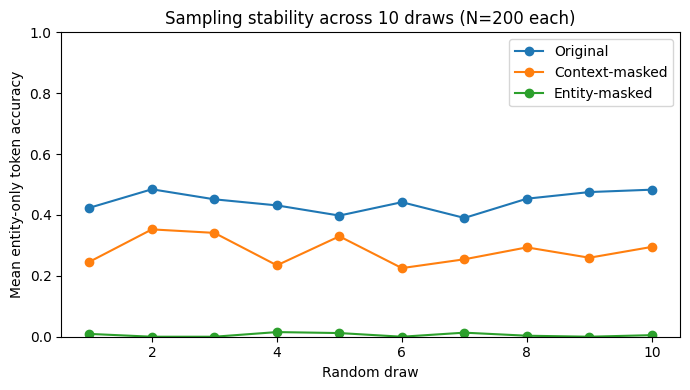

Saved: results/robustness_multiple_draws.csv, results/table8_sampling_stability.csv, results/robustness_multiple_draws_summary.json, results/robustness_multiple_draws.png


In [18]:
import numpy as np, pandas as pd, json
import matplotlib.pyplot as plt

# Sampling stability across random subsets

def eval_subset(indices):
    subset = ds["test"].select(sorted(indices.tolist()))
    rows = []
    for ex in subset:
        tokens = ex["tokens"]
        gold_ids = ex["ner_tags"]
        sent = " ".join(tokens)
        gold_labels = [map_wnut_to_coarse(label_names[i]) for i in gold_ids]

        # Original
        pred_orig = get_token_labels(tokens, ner_pipe(sent), sent)

        # Entity-masked
        ent_tokens = mask_entity_tokens(tokens, gold_ids)
        ent_sent = " ".join(ent_tokens)
        pred_ent = get_token_labels(ent_tokens, ner_pipe(ent_sent), ent_sent)

        # Context-masked
        ctx_tokens = mask_context_tokens(tokens, gold_ids)
        ctx_sent = " ".join(ctx_tokens)
        pred_ctx = get_token_labels(ctx_tokens, ner_pipe(ctx_sent), ctx_sent)

        rows.append({
            "original":       filtered_accuracy(gold_labels, pred_orig),
            "entity_masked":  filtered_accuracy(gold_labels, pred_ent),
            "context_masked": filtered_accuracy(gold_labels, pred_ctx),
        })

    return pd.DataFrame(rows)

# run DRAWS draws of size N
DRAWS = 10
N = 200
test_size = len(ds["test"])
rng_local = np.random.default_rng(42)

draw_rows = []
for d in range(DRAWS):
    indices = rng_local.choice(test_size, size=min(N, test_size), replace=False)
    df_draw = eval_subset(indices)

    orig = float(df_draw["original"].mean())
    ent  = float(df_draw["entity_masked"].mean())
    ctx  = float(df_draw["context_masked"].mean())
    retained = (ctx / orig) if orig > 0 else np.nan

    draw_rows.append({
        "draw": d + 1,
        "original_mean": orig,
        "context_masked_mean": ctx,
        "entity_masked_mean": ent,
        "retained_context": retained
    })

draw_df = pd.DataFrame(draw_rows)

# Table 8: mean & SD across draws
table8 = draw_df[["original_mean","context_masked_mean","entity_masked_mean","retained_context"]].agg(["mean","std"]).T
table8.columns = ["Mean", "Standard Deviation"]

# percent formatting for retained_context
table8_display = table8.copy()
table8_display.loc["retained_context", ["Mean", "Standard Deviation"]] *= 100
table8_display = table8_display.rename(index={
    "original_mean": "Original",
    "context_masked_mean": "Context-masked",
    "entity_masked_mean": "Entity-masked",
    "retained_context": "Retained context (Context / Original)"
})

display(table8_display)

# Save artifacts used by the thesis
draw_df.to_csv("results/robustness_multiple_draws.csv", index=False)
table8_display.to_csv("results/table8_sampling_stability.csv")

with open("results/robustness_multiple_draws_summary.json", "w") as f:
    json.dump({
        "per_draw": draw_rows,
        "table8_mean_sd": table8_display.to_dict()
    }, f, indent=2)

# Plot (Figure for robustness section)
plt.figure(figsize=(7,4))
plt.plot(draw_df["draw"], draw_df["original_mean"], marker="o", label="Original")
plt.plot(draw_df["draw"], draw_df["context_masked_mean"], marker="o", label="Context-masked")
plt.plot(draw_df["draw"], draw_df["entity_masked_mean"], marker="o", label="Entity-masked")
plt.ylabel("Mean entity-only token accuracy")
plt.xlabel("Random draw")
plt.title(f"Sampling stability across {DRAWS} draws (N={N} each)")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig("results/robustness_multiple_draws.png", dpi=300)
plt.show()

print("Saved: results/robustness_multiple_draws.csv, results/table8_sampling_stability.csv, results/robustness_multiple_draws_summary.json, results/robustness_multiple_draws.png")

,config,entity_mask_token,context_mask_token,orig_mean,ent_mask_mean,ctx_mask_mean,retained_ctx,drop_ent,drop_ctx
0,[MASK] baseline,[MASK],[MASK],0.42356,0.009259,0.246091,0.581006,0.414300,0.177469
1,[UNK] entity,[UNK],[MASK],0.42356,0.067901,0.246091,0.581006,0.355658,0.177469
2,X entity,X,[MASK],0.42356,0.204321,0.246091,0.581006,0.219239,0.177469
3,ENTITY string,ENTITY,[MASK],0.42356,0.057870,0.246091,0.581006,0.365689,0.177469
4,Typed placeholders,[MASK],[MASK],0.42356,0.584825,0.246091,0.581006,-0.161265,0.177469


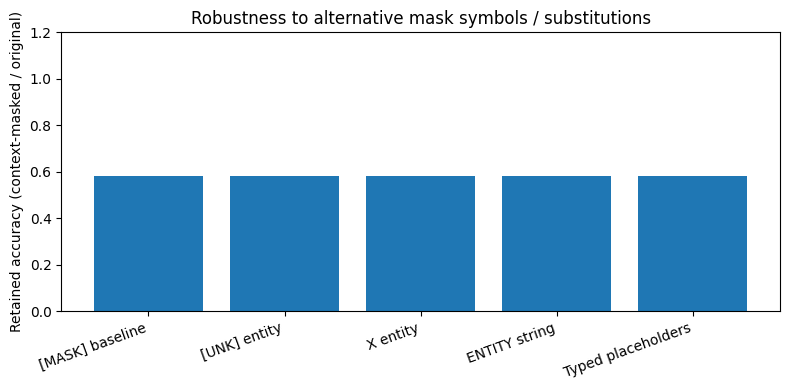

Saved: results/robustness_alt_masks.csv, .json, .png


In [19]:
import pandas as pd, json
import matplotlib.pyplot as plt

def mask_entity_tokens_custom(tokens, gold_ids, mask_token="[MASK]", subst=None):
    out = []
    for t, i in zip(tokens, gold_ids):
        if label_names[i] != "O":
            if subst is None:
                out.append(mask_token)
            else:
                out.append(subst(map_wnut_to_coarse(label_names[i])))
        else:
            out.append(t)
    return out

def mask_context_tokens_custom(tokens, gold_ids, mask_token="[MASK]"):
    return [mask_token if label_names[i] == "O" else t for t, i in zip(tokens, gold_ids)]

def summarize(df, seed=42, n_boot=1000):
    rng = np.random.default_rng(seed)
    summ = {}
    for col in ["original","entity_masked","context_masked"]:
        m, (lo, hi) = boot_mean_ci(df[col], n_boot=n_boot, alpha=0.05, rng_=rng)
        summ[col] = {"mean": m, "ci_low": lo, "ci_high": hi}
    drops = {
        "entity": summ["original"]["mean"] - summ["entity_masked"]["mean"],
        "context": summ["original"]["mean"] - summ["context_masked"]["mean"],
        "retained_context": (summ["context_masked"]["mean"] / summ["original"]["mean"]) if summ["original"]["mean"] > 0 else np.nan
    }
    return summ, drops

def run_alt_mask_eval(N=200, seed=42, entity_mask_token="[MASK]", context_mask_token="[MASK]", entity_subst_fn=None):
    rng = np.random.default_rng(seed)
    test_size = len(ds["test"])
    indices = rng.choice(test_size, size=min(N, test_size), replace=False)
    subset = ds["test"].select(sorted(indices.tolist()))

    rows = []
    for ex in subset:
        tokens = ex["tokens"]
        gold_ids = ex["ner_tags"]
        sent = " ".join(tokens)
        gold_labels = [map_wnut_to_coarse(label_names[i]) for i in gold_ids]

        # original
        pred_orig = get_token_labels(tokens, ner_pipe(sent), sent)

        # entity-masked (custom)
        ent_tokens = mask_entity_tokens_custom(tokens, gold_ids, mask_token=entity_mask_token, subst=entity_subst_fn)
        ent_masked = " ".join(ent_tokens)
        pred_ent   = get_token_labels(ent_tokens, ner_pipe(ent_masked), ent_masked)

        # context-masked (custom)
        ctx_tokens = mask_context_tokens_custom(tokens, gold_ids, mask_token=context_mask_token)
        ctx_masked = " ".join(ctx_tokens)
        pred_ctx   = get_token_labels(ctx_tokens, ner_pipe(ctx_masked), ctx_masked)

        rows.append({
            "original": filtered_accuracy(gold_labels, pred_orig),
            "entity_masked": filtered_accuracy(gold_labels, pred_ent),
            "context_masked": filtered_accuracy(gold_labels, pred_ctx),
        })

    df = pd.DataFrame(rows)
    summ, drops = summarize(df, seed=seed, n_boot=1000)
    return summ, drops

# substitution function for "light-touch" placeholders
def placeholder_by_type(coarse):
    return {"PER":"John", "ORG":"Acme", "LOC":"Paris", "MISC":"Thing"}.get(coarse, "Thing")

configs = [
    ("[MASK] baseline", "[MASK]", "[MASK]", None),
    ("[UNK] entity",    "[UNK]",  "[MASK]", None),
    ("X entity",        "X",      "[MASK]", None),
    ("ENTITY string",   "ENTITY", "[MASK]", None),
    ("Typed placeholders", "[MASK]", "[MASK]", placeholder_by_type),
]

results = []
for name, ent_tok, ctx_tok, subst in configs:
    summ, drops = run_alt_mask_eval(
        N=200, seed=42,
        entity_mask_token=ent_tok,
        context_mask_token=ctx_tok,
        entity_subst_fn=subst
    )
    results.append({
        "config": name,
        "entity_mask_token": ent_tok,
        "context_mask_token": ctx_tok,
        "orig_mean": summ["original"]["mean"],
        "ent_mask_mean": summ["entity_masked"]["mean"],
        "ctx_mask_mean": summ["context_masked"]["mean"],
        "retained_ctx": drops["retained_context"],
        "drop_ent": drops["entity"],
        "drop_ctx": drops["context"],
    })

alt_df = pd.DataFrame(results)
alt_df.to_csv("results/robustness_alt_masks.csv", index=False)
with open("results/robustness_alt_masks_summary.json", "w") as f:
    json.dump(results, f, indent=2)

display(alt_df)

# plot retained context ratio by config
plt.figure(figsize=(8,4))
plt.bar(alt_df["config"], alt_df["retained_ctx"])
plt.ylabel("Retained accuracy (context-masked / original)")
plt.title("Robustness to alternative mask symbols / substitutions")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1.2)
plt.tight_layout()
plt.savefig("results/robustness_alt_masks.png", dpi=300)
plt.show()

print("Saved: results/robustness_alt_masks.csv, .json, .png")

align_fail_original          0.000000
align_fail_entity_masked     0.082838
align_fail_context_masked    0.907320
dtype: float64


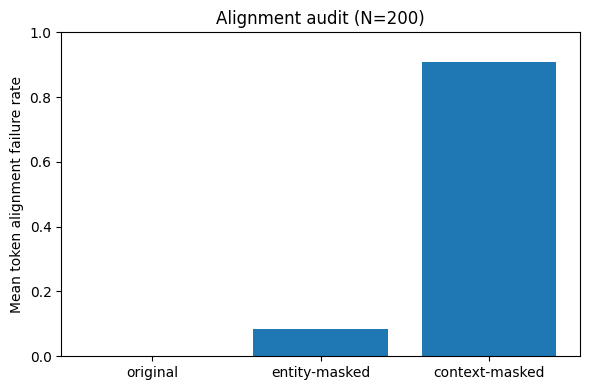

Saved: results/robustness_alignment_audit.csv, .png


In [14]:
def alignment_failure_rate(tokens, sentence):
    cursor = 0
    fails = 0
    for t in tokens:
        pos = sentence.find(t, cursor)
        if pos == -1:
            fails += 1
        else:
            cursor = pos + len(t)
    return fails / len(tokens) if tokens else np.nan

N = 200
rng = np.random.default_rng(42)
indices = rng.choice(len(ds["test"]), size=min(N, len(ds["test"])), replace=False)
subset = ds["test"].select(sorted(indices.tolist()))

audit_rows=[]
for ex in subset:
    tokens = ex["tokens"]
    gold_ids = ex["ner_tags"]

    sent_o = " ".join(tokens)
    sent_e = " ".join(mask_entity_tokens(tokens, gold_ids))
    sent_c = " ".join(mask_context_tokens(tokens, gold_ids))

    audit_rows.append({
        "align_fail_original": alignment_failure_rate(tokens, sent_o),
        "align_fail_entity_masked": alignment_failure_rate(tokens, sent_e),
        "align_fail_context_masked": alignment_failure_rate(tokens, sent_c),
    })

audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv("results/robustness_alignment_audit.csv", index=False)

print(audit_df.mean())

plt.figure(figsize=(6,4))
plt.bar(["original","entity-masked","context-masked"],
        [audit_df["align_fail_original"].mean(),
         audit_df["align_fail_entity_masked"].mean(),
         audit_df["align_fail_context_masked"].mean()])
plt.ylabel("Mean token alignment failure rate")
plt.title(f"Alignment audit (N={N})")
plt.ylim(0,1)
plt.tight_layout()
plt.savefig("results/robustness_alignment_audit.png", dpi=300)
plt.show()

print("Saved: results/robustness_alignment_audit.csv, .png")
